__Классификация аудиоданных.__ 

Евгений Борисов esborisov@sevsu.ru


----

Understand Audio data.   
https://www.geeksforgeeks.org/understand-audio-data/

Классификация аудиофайлов с библиотекой Librosa.     
https://habr.com/ru/companies/otus/articles/741080/

Music Information Retrieval    
https://musicinformationretrieval.com

Understanding Origins and Fusion of Music Genres     
https://shouvikmani.github.io/Million-Song-Dataset-Visualization/index.html

In [ ]:
# pip install librosa

## загружаем данные 

George Tzanetakis, Georg Essl, Perry Cook    Automatic Musical Genre Classification Of Audio Signals.   
https://ismir2001.ismir.net/pdf/tzanetakis.pdf   

Raw data is 1.2GB and consists of 1000 audio files(.au) divided into 10 folders for 10 genres equally. I.e Every genre has 100 audio files.

http://opihi.cs.uvic.ca/sound/genres.tar.gz

https://drive.google.com/drive/folders/189jIlfQ-E94eHfKVksbAUSXKX68Ju1GI

https://www.kaggle.com/datasets/andradaolteanu/gtzan-dataset-music-genre-classification

In [1]:
data_folder = 'data'

In [2]:
import os
import pandas as pd
from tqdm.cli import tqdm
tqdm.pandas()

In [3]:
files = pd.DataFrame([ 
        { 
            'fpath': f'{data_folder}/genres_original/{genre}/{fname}', 
            'genre': genre, 
        } 
        for genre in os.listdir(f'{data_folder}/genres_original/')
        for fname in os.listdir(f'{data_folder}/genres_original/{genre}')
    ]).reset_index(drop=True)

display( len(files) )
display( files.sample(5) )

1000

,fpath,genre
72,data/genres_original/reggae/reggae.00012.wav,reggae
473,data/genres_original/metal/metal.00095.wav,metal
619,data/genres_original/blues/blues.00071.wav,blues
241,data/genres_original/jazz/jazz.00060.wav,jazz
606,data/genres_original/blues/blues.00061.wav,blues


In [4]:
files = files.sample(len(files)//10)

In [5]:
files.groupby('genre').count()

,fpath
genre,
blues,9
classical,17
country,9
disco,13
hiphop,7
jazz,10
metal,10
pop,7
reggae,10


# признаки в аудиоданных

In [6]:
import numpy as np
import numpy.random as rng
import matplotlib.pyplot as plt

In [7]:
# from pydub import AudioSegment
from IPython.display import Audio

In [8]:
import librosa as lrs
from librosa.display import waveshow
from librosa.display import specshow
from librosa import feature

In [9]:
# lrs.version.show_versions()

In [10]:
# files

In [11]:
# pip install ipywidgets

In [12]:
# выберем рандомный пример
fpath, genre = files.sample()[['fpath','genre']].values[0]
data, rate = lrs.load(fpath)
display( (fpath, genre, data.shape, rate) )

display( f'Duration: { lrs.get_duration(y=data,sr=rate):.2f} sec' )
display(f'Sample Rate: {rate}')
display(f'Amplitude Range: {(data.max()-data.min()):.3f}')
display(f'Bit Depth: {data.dtype.itemsize} bits')
tempo, beat_frames = lrs.beat.beat_track(y=data, sr=rate)
print(f'Estimated tempo: {tempo[0]:.2f} beats per minute')

display( Audio(data=data,rate=rate,autoplay=False) )

('data/genres_original/reggae/reggae.00050.wav', 'reggae', (661504,), 22050)

'Duration: 30.00 sec'

'Sample Rate: 22050'

'Amplitude Range: 1.864'

'Bit Depth: 4 bits'

Estimated tempo: 95.70 beats per minute


Text(0.5, 1.0, 'data/genres_original/reggae/reggae.00050.wav')

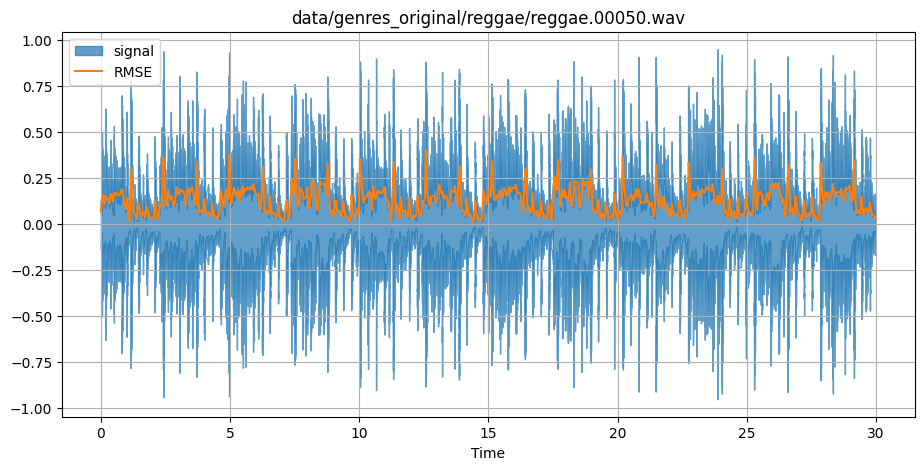

In [13]:
# Root-mean square energy
data_rms = feature.rms(y=data, frame_length=1024, hop_length=1024)[0]
t = lrs.times_like(data_rms, hop_length=1024, sr=rate)

fig,ax = plt.subplots(figsize=(11, 5))
waveshow(y=data, sr=rate, alpha=.7, ax=ax, label='signal')
ax.plot( t, data_rms, label='RMSE' )
ax.grid()
ax.legend()
ax.set_title(fpath)

In [ ]:
# y = feature.zero_crossing_rate(data)
# fig,ax = plt.subplots(figsize=(11, 5))
# # логарифмическaя шкала по оси Y и линейная — по оси X
# # ax.semilogy(y.T, label='Fraction') 
# ax.plot(y.T)
# ax.set_title('zero_crossing_rate')
# ax.grid()
# plt.show()

In [ ]:
# feature.zero_crossing_rate(data)
# feature.spectral_centroid(y=data, sr=rate)
# feature.spectral_rolloff(y=data, sr=rate)
# feature.chroma_stft(y=data, sr=rate)
# feature.spectral_bandwidth(y=data, sr=rate).std()
# feature.tonnetz(y=data, sr=rate).

In [ ]:
# plt.plot( data, alpha=0.7 )
# plt.plot( lrs.effects.harmonic(data) )

# C = np.abs(lrs.cqt(y=data, sr=rate, fmin=lrs.note_to_hz('A1')))
# freqs = lrs.cqt_frequencies(C.shape[0],fmin=lrs.note_to_hz('A1'))
# perceptual_CQT = librosa.perceptual_weighting(C**2,freqs, ref=np.max)

In [ ]:
# from scipy.fft import fft

# # Compute the FFT of the waveform
# spectrum = fft(data)
 
# # Frequency bins
# frequencies = np.fft.fftfreq(len(spectrum), 1 / rate)
 
# # Plot the frequency spectrum
# plt.figure(figsize=(8, 4))
# plt.plot(frequencies[:len(frequencies)//2], np.abs(spectrum[:len(spectrum)//2]))
# plt.xlabel('Frequency (Hz)')
# plt.ylabel('Amplitude')
# plt.title('Frequency Spectrum')
# plt.grid(True)
# plt.show()


In [ ]:
# f

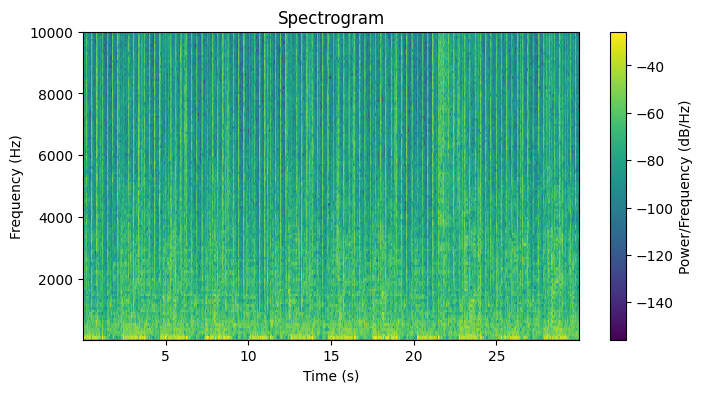

In [14]:
# Compute the spectrogram
from scipy.signal import spectrogram
    
# Small constant to avoid division by zero(if any)
epsilon = 1e-40 
f, t, Sxx = spectrogram(data, fs=rate)
 
# Plot the spectrogram with the constant added to Sxx
fig,ax = plt.subplots(1,figsize=(8, 4))
im = ax.pcolormesh(t, f, 10. * np.log10(Sxx + epsilon))
plt.colorbar(im,label='Power/Frequency (dB/Hz)')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Frequency (Hz)')
ax.set_ylim((20,10_000))
ax.set_title('Spectrogram')
plt.show()

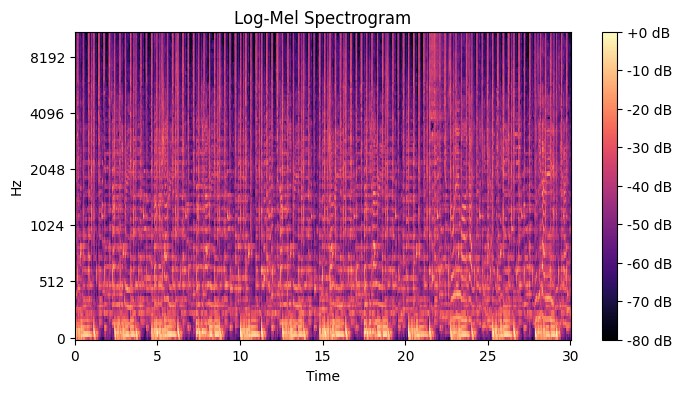

In [15]:
# visualizing log-mel spectrogram
def compute_logmel_spectrogram(y, sr, n_mels=128, hop_length=512):
    mel_spectrogram = feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, hop_length=hop_length)
    logmel_spectrogram = lrs.power_to_db(mel_spectrogram, ref=np.max)
    return logmel_spectrogram

# Compute log-mel spectrogram
logmel_spectrogram = compute_logmel_spectrogram(data, sr=rate)

  
# Plot the spectrogram with the constant added to Sxx
fig,ax = plt.subplots(1,figsize=(8, 4))
# Display the log-mel spectrogram
im = specshow(logmel_spectrogram, sr=rate, hop_length=512, x_axis='time', y_axis='mel',ax=ax)
plt.colorbar(im,format='%+2.0f dB')
ax.set_title('Log-Mel Spectrogram')
plt.show()

# формируем датасет

In [ ]:
# %%time

# def music_features(fpath):
#     try:
#         data, rate = lrs.load(fpath)
            
#         tempo, _ = lrs.beat.beat_track(y=data, sr=rate)
#         zc = feature.zero_crossing_rate(data)
#         rms = feature.rms(y=data)
#         cent = feature.spectral_centroid(y=data, sr=rate)
#         rolloff = feature.spectral_rolloff(y=data, sr=rate)
#         cstft = feature.chroma_stft(y=data, sr=rate)
#         sbandwidth = feature.spectral_bandwidth(y=data, sr=rate)
#         tonnetz = feature.tonnetz(y=data, sr=rate)
#         # harmonic = lrs.effects.harmonic(data)
#         # mfcc = [ feature.mfcc(y=data,sr=rate,n_mels=n) for n in range(10,21,5) ]
#         # mfcc = [ feature.mfcc(y=data,sr=rate) ]
        
#         return np.hstack([
#             np.array([
#                 zc.mean(),zc.std(),
#                 rms.mean(),rms.std(),
#                 cent.mean(),cent.std(),
#                 rolloff.mean(),rolloff.std(),
#                 # harmonic.mean(),harmonic.std(),
#             ]),
#             cstft.mean(axis=1),cstft.std(axis=1),
#             sbandwidth.mean(axis=1),sbandwidth.std(axis=1),
#             tonnetz.mean(axis=1),tonnetz.std(axis=1),
#             tempo,
#             ])
#             #+ [ m.mean(axis=1) for m in mfcc ] + [ m.std(axis=1) for m in mfcc ]
#     except:
#         pass

#     return np.array([])

# features = files['fpath'].progress_apply(music_features)

In [16]:
# data = files.copy()
# data['features'] = features
# data = data[ data['features'].str.len()>0 ]

In [17]:
# data.iloc[0]['features']

In [18]:
# cols_features = [ 'features' ]

----

In [19]:
import pandas as pd
data = pd.read_csv( f'{data_folder}/features_3_sec.csv.gz').convert_dtypes()
display( len(data) )
display( data.sample(5) )

9990

,filename,length,chroma_stft_mean,chroma_stft_var,rms_mean,rms_var,spectral_centroid_mean,spectral_centroid_var,spectral_bandwidth_mean,spectral_bandwidth_var,...,mfcc16_var,mfcc17_mean,mfcc17_var,mfcc18_mean,mfcc18_var,mfcc19_mean,mfcc19_var,mfcc20_mean,mfcc20_var,label
8766,reggae.00077.4.wav,66149,0.353525,0.094428,0.12377,0.001214,1787.645099,355028.955042,2251.52269,180204.566616,...,40.182926,-8.934486,49.875572,-1.968788,14.903305,-0.819802,17.726439,-0.531523,32.485622,reggae
6631,metal.00063.9.wav,66149,0.494691,0.074728,0.090966,0.000272,2305.771556,177686.174072,1936.819958,47098.16309,...,36.415234,-6.912527,46.794529,2.640057,42.336185,-7.304892,23.129917,0.5854,24.595827,metal
9025,rock.00003.3.wav,66149,0.387751,0.093479,0.149162,0.002536,1775.268595,455710.651578,2098.944632,139610.84452,...,25.523716,-3.852409,24.463736,0.916526,31.791132,-0.467185,25.28344,1.309325,27.974901,rock
4878,hiphop.00088.6.wav,66149,0.41167,0.099559,0.09954,0.001807,2692.892563,631685.647588,2346.297553,62267.614191,...,110.165771,-7.714511,69.563744,2.209452,88.359825,-5.734133,51.507744,-1.296867,93.316551,hiphop
9879,rock.00088.9.wav,66149,0.324361,0.088101,0.128351,0.000634,2461.658145,413390.983736,2109.371805,120830.19068,...,60.765347,-9.119296,84.479729,8.174566,78.413704,-2.816771,44.953018,-1.081695,84.153107,rock


In [23]:
cols_features = [
    'chroma_stft_mean', 'chroma_stft_var', 'rms_mean',
    'rms_var', 'spectral_centroid_mean', 'spectral_centroid_var',
    'spectral_bandwidth_mean', 'spectral_bandwidth_var', 'rolloff_mean',
    'rolloff_var', 'zero_crossing_rate_mean', 'zero_crossing_rate_var',
    'harmony_mean', 'harmony_var', 'perceptr_mean', 'perceptr_var', 'tempo',
    'mfcc1_mean', 'mfcc1_var', 'mfcc2_mean', 'mfcc2_var', 'mfcc3_mean',
    'mfcc3_var', 'mfcc4_mean', 'mfcc4_var', 'mfcc5_mean', 'mfcc5_var',
    'mfcc6_mean', 'mfcc6_var', 'mfcc7_mean', 'mfcc7_var', 'mfcc8_mean',
    'mfcc8_var', 'mfcc9_mean', 'mfcc9_var', 'mfcc10_mean', 'mfcc10_var',
    'mfcc11_mean', 'mfcc11_var', 'mfcc12_mean', 'mfcc12_var', 'mfcc13_mean',
    'mfcc13_var', 'mfcc14_mean', 'mfcc14_var', 'mfcc15_mean', 'mfcc15_var',
    'mfcc16_mean', 'mfcc16_var', 'mfcc17_mean', 'mfcc17_var', 'mfcc18_mean',
    'mfcc18_var', 'mfcc19_mean', 'mfcc19_var', 'mfcc20_mean', 'mfcc20_var',
]

# визуализация данных

In [29]:
# x =  np.vstack(data['features'].tolist())
x = data[cols_features].values
labels = { g:n for n,g in enumerate(sorted(set(data['label']))) } 
target = data['label'].map(labels).values

<function matplotlib.pyplot.show(close=None, block=None)>

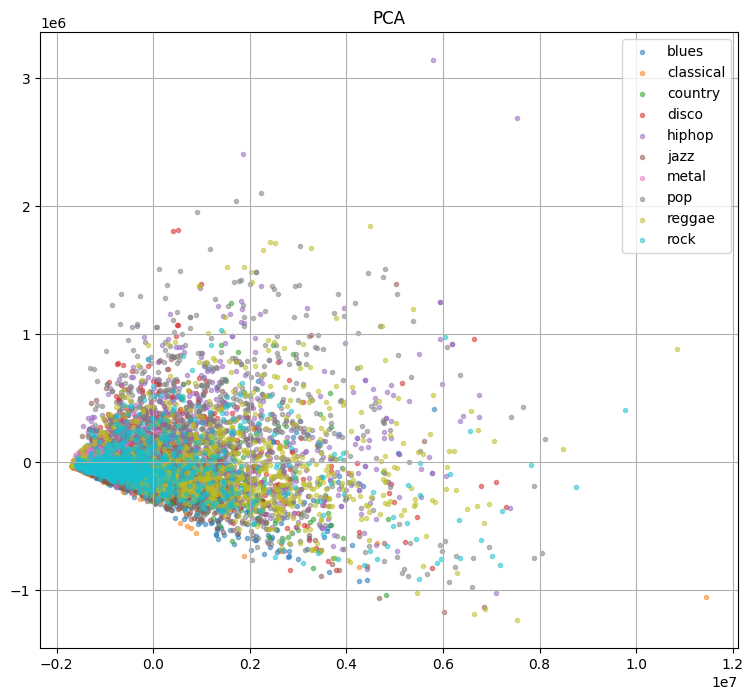

In [26]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

data[['pca_x2_0','pca_x2_1']] = PCA(n_components=2).fit_transform( x )
fig, ax = plt.subplots(figsize=(9,8))
for label, group in data.groupby('label'):
    ax.scatter(group['pca_x2_0'], group['pca_x2_1'], label=label, s=9, alpha=0.5 ) 
ax.legend()
ax.set_title('PCA')
ax.grid()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

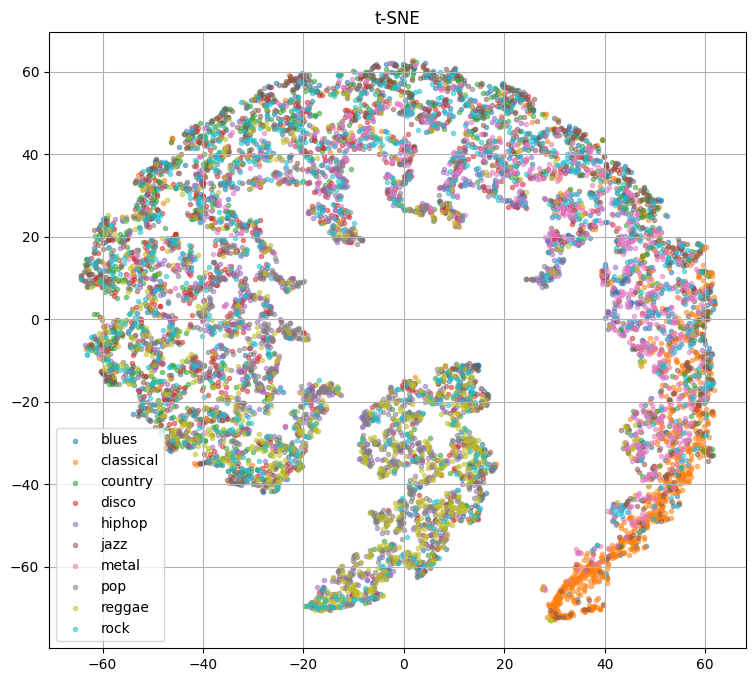

In [27]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

data[['tsne_x2_0','tsne_x2_1']] = TSNE(n_components=2, learning_rate='auto', init='random', perplexity=64).fit_transform( x )

fig, ax = plt.subplots(figsize=(9,8))
for label, group in data.groupby('label'):
    ax.scatter(group['tsne_x2_0'], group['tsne_x2_1'], label=label, s=9, alpha=0.5 ) 
ax.legend()
ax.set_title('t-SNE')
ax.grid()
plt.show


# обучаем классификатор

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, target_train, target_test = train_test_split(x,target,test_size=0.3)
display( x_train.shape, target_train.shape, x_test.shape, target_test.shape )

(6993, 57)

(6993,)

(2997, 57)

(2997,)

In [31]:
# from sklearn.preprocessing import StandardScaler as Scaler
from  sklearn.preprocessing import RobustScaler as Scaler
scaler = Scaler().fit(x_train)
x_train_ = scaler.transform(x_train)
x_test_ = scaler.transform(x_test)

---

In [40]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier().fit(x_train_,target_train)

In [ ]:
# pip install xgboost
# pip install xgboost-cpu

In [ ]:
# from xgboost import XGBClassifier
# model = XGBClassifier(
#         n_estimators=1024, 
#         learning_rate=0.05, 
#         # device='cuda:1'
#         device='cpu'
#     ).fit(x_train_,target_train)

In [41]:
# from sklearn.linear_model import SGDClassifier
# model = SGDClassifier().fit(x_train_,target_train)

In [42]:
# from sklearn.linear_model import LogisticRegression
# model = LogisticRegression().fit(x_train_,target_train)

In [43]:
o_train = model.predict(x_train_)
o_test = model.predict(x_test_)

# результаты

In [44]:
from sklearn.metrics import accuracy_score

# доля правильных ответов на учебном наборе
display( accuracy_score(target_train,o_train) )

# доля правильных ответов на тестовом наборе
display(  accuracy_score(target_test,o_test) )

0.9995709995709996

0.8728728728728729

In [45]:
from sklearn.metrics import classification_report
# labels = sorted(set(df['label']))
print( classification_report( target_test, o_test, target_names=labels) )

              precision    recall  f1-score   support

       blues       0.90      0.88      0.89       294
   classical       0.92      0.94      0.93       309
     country       0.77      0.86      0.82       299
       disco       0.86      0.86      0.86       321
      hiphop       0.91      0.86      0.88       284
        jazz       0.82      0.90      0.86       295
       metal       0.88      0.96      0.92       272
         pop       0.94      0.87      0.91       300
      reggae       0.88      0.86      0.87       328
        rock       0.87      0.74      0.80       295

    accuracy                           0.87      2997
   macro avg       0.88      0.87      0.87      2997
weighted avg       0.87      0.87      0.87      2997



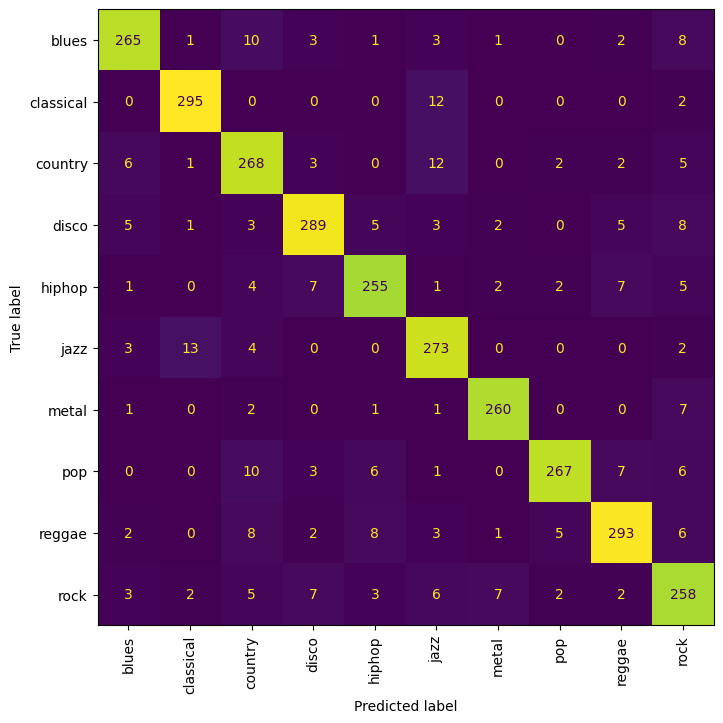

In [36]:
from matplotlib import pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

fig,ax = plt.subplots(figsize=(8,8))
ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(target_test,o_test), 
        display_labels=labels,
    ).plot(
        ax=ax, 
        xticks_rotation='vertical', 
        include_values=True, 
        cmap='viridis',  
        colorbar=False,
    )
# plt.show()